In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [4]:
"""Data loading utilities."""
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

def load_mnist(batch_size=64):
    """Load MNIST dataset. Returns (train_loader, test_loader)."""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    
    train = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test = datasets.MNIST('./data', train=False, download=True, transform=transform)
    
    return (DataLoader(train, batch_size=batch_size, shuffle=True),
            DataLoader(test, batch_size=batch_size, shuffle=False))

## Exercise 1

In [ ]:
class DigitClassifier(nn.Module):
    def __init__(self, hidden_sizes=[128, 64]):
        super().__init__()
        layers = []
        input_size = 28 * 28 
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.ReLU())
            input_size = hidden_size
        layers.append(nn.Linear(input_size, 10))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)



## Exercise 2

In [9]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    avg_loss = total_loss / len(train_loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


def evaluate(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    avg_loss = total_loss / len(test_loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


def train_model(model, train_loader, test_loader, epochs=10, lr=0.001, device='cpu', progress=True):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': []
    }
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        if progress:
            print(f'Epoch {epoch+1}/{epochs}:')
            print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
            print(f'  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')
    return history

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_loader, test_loader = load_mnist(batch_size=64)
model = DigitClassifier(hidden_sizes=[128, 64])
history = train_model(model, train_loader, test_loader, epochs=10, lr=0.001, device=device)
final_acc = history['test_acc'][-1]
print(f"Final Test Accuracy: {final_acc:.2f}%")

Epoch 1/10:
  Train Loss: 0.2650, Train Acc: 92.08%
  Test Loss: 0.1402, Test Acc: 95.80%
Epoch 2/10:
  Train Loss: 0.1111, Train Acc: 96.61%
  Test Loss: 0.1036, Test Acc: 96.68%
Epoch 3/10:
  Train Loss: 0.0797, Train Acc: 97.53%
  Test Loss: 0.0906, Test Acc: 97.09%
Epoch 4/10:
  Train Loss: 0.0618, Train Acc: 97.97%
  Test Loss: 0.0831, Test Acc: 97.31%
Epoch 5/10:
  Train Loss: 0.0489, Train Acc: 98.44%
  Test Loss: 0.0772, Test Acc: 97.68%
Epoch 6/10:
  Train Loss: 0.0402, Train Acc: 98.67%
  Test Loss: 0.0850, Test Acc: 97.50%
Epoch 7/10:
  Train Loss: 0.0355, Train Acc: 98.78%
  Test Loss: 0.0802, Test Acc: 97.65%
Epoch 8/10:
  Train Loss: 0.0286, Train Acc: 99.01%
  Test Loss: 0.0884, Test Acc: 97.70%
Epoch 9/10:
  Train Loss: 0.0249, Train Acc: 99.17%
  Test Loss: 0.0908, Test Acc: 97.68%
Epoch 10/10:
  Train Loss: 0.0222, Train Acc: 99.24%
  Test Loss: 0.0974, Test Acc: 97.67%
Final Test Accuracy: 97.67%


## Exercise 3

In [15]:
def run_experiments():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    train_loader, test_loader = load_mnist(batch_size=64)
    experiments = [
        {'name': 'Shallow (128)', 'hidden': [128], 'lr': 0.001, 'epochs': 10},
        {'name': 'Medium/Normal LR (128, 64)', 'hidden': [128, 64], 'lr': 0.001, 'epochs': 10},
        {'name': 'Deep (256, 128, 64)', 'hidden': [256, 128, 64], 'lr': 0.001, 'epochs': 10},
        {'name': 'Wide (512, 256)', 'hidden': [512, 256], 'lr': 0.001, 'epochs': 10},
        {'name': 'High LR (128, 64)', 'hidden': [128, 64], 'lr': 0.01, 'epochs': 10},
        {'name': 'Low LR (128, 64)', 'hidden': [128, 64], 'lr': 0.0001, 'epochs': 10},
    ]
    results = []
    for exp in experiments:
        print(f'Running {exp['name']}')
        model = DigitClassifier(hidden_sizes=exp['hidden'])
        history = train_model(
            model, train_loader, test_loader,
            epochs=exp['epochs'], lr=exp['lr'], device=device, progress=False
        )
        final_test_acc = history['test_acc'][-1]
        results.append({
            'name': exp['name'],
            'hidden': exp['hidden'],
            'lr': exp['lr'],
            'final_acc': final_test_acc,
            'history': history
        })
    return results


In [16]:
results = run_experiments()

Running Shallow (128)
Running Medium/Normal LR (128, 64)
Running Deep (256, 128, 64)
Running Wide (512, 256)
Running High LR (128, 64)
Running Low LR (128, 64)


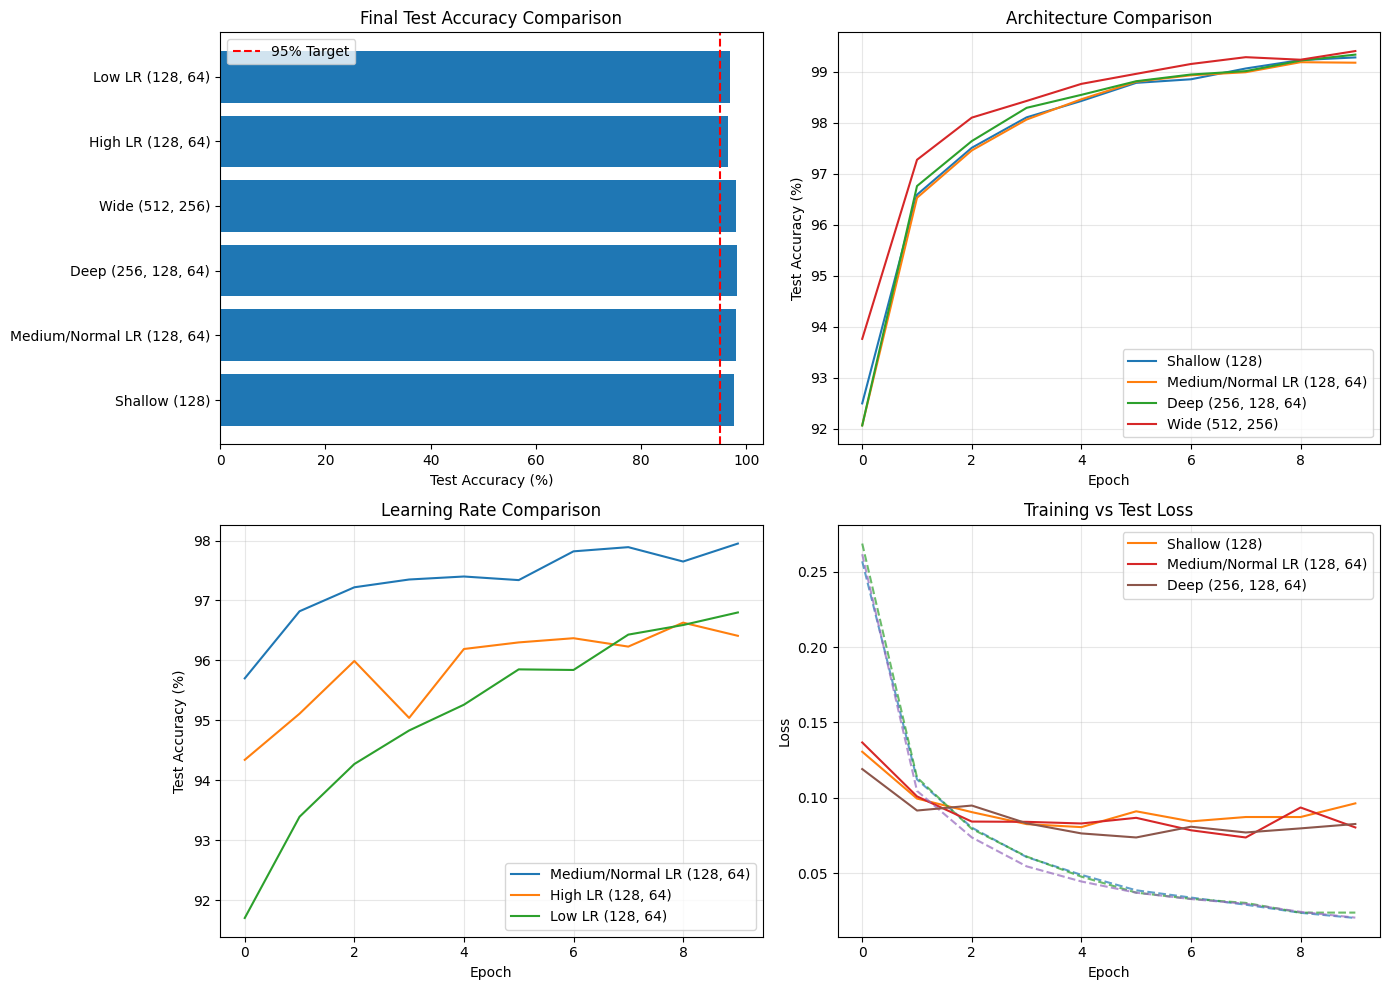

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
names = [r['name'] for r in results]
accs = [r['final_acc'] for r in results]
axes[0, 0].barh(names, accs)
axes[0, 0].axvline(x=95, color='r', linestyle='--', label='95% Target')
axes[0, 0].set_xlabel('Test Accuracy (%)')
axes[0, 0].set_title('Final Test Accuracy Comparison')
axes[0, 0].legend()

for r in results[:4]:  
    axes[0, 1].plot(r['history']['train_acc'], label=r['name'])
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Test Accuracy (%)')
axes[0, 1].set_title('Architecture Comparison')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

lr_results = [r for r in results if 'LR' in str(r['name'])]
for r in lr_results:
    axes[1, 0].plot(r['history']['test_acc'], label=r['name'])
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Test Accuracy (%)')
axes[1, 0].set_title('Learning Rate Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

for r in results[:3]:
    axes[1, 1].plot(r['history']['train_loss'], '--', alpha=0.7)
    axes[1, 1].plot(r['history']['test_loss'], '-', label=r['name'])
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_title('Training vs Test Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()    


In [22]:
print(f"{'Configuration':<30} {'Architecture':<20} {'LR':<10} {'Test Acc (%)':<12}")
for r in results:
    print(f"{r['name']:<30} {str(r['hidden']):<20} {r['lr']:<10.4f} {r['final_acc']:<12.2f}")

Configuration                  Architecture         LR         Test Acc (%)
Shallow (128)                  [128]                0.0010     97.54       
Medium/Normal LR (128, 64)     [128, 64]            0.0010     97.95       
Deep (256, 128, 64)            [256, 128, 64]       0.0010     98.14       
Wide (512, 256)                [512, 256]           0.0010     97.98       
High LR (128, 64)              [128, 64]            0.0100     96.41       
Low LR (128, 64)               [128, 64]            0.0001     96.80       
